En términos del tiempo conforme, las ecuaciones que queremos resolver son:

$$\tilde{\phi}^{\prime \prime} + 3 \mathcal{H} \tilde{\phi}^\prime + a^2 \tilde{\phi}^3 = 0$$

$$\tilde{\chi}^{\prime \prime} + 3 \mathcal{H} \tilde{\chi}^\prime + \left( \tilde{k}^2 + a^2 g^2 \tilde{\phi}^2 \right) \tilde{\chi} = 0$$

dónde tomaremos que como estamos en radiación:

$$a(\eta) = 1 + \sqrt{\frac{1}{3} \left( \frac{\dot{\phi}_0^2}{2} + \frac{\phi^4_0}{4} \right)} \eta$$

In [1]:
import os
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d
from scipy.integrate import dblquad, quad
from scipy.integrate import solve_ivp, simpson


In [2]:
mpl.rc('figure', figsize=(12, 6))
mpl.rc('text', usetex = False)
mpl.rc('font', family = 'serif')
mpl.rc('font', size = '14')
mpl.rc('xtick', labelsize=14) 
mpl.rc('ytick', labelsize=14)
mpl.rcParams['mathtext.fontset'] = 'stix'

In [3]:
# Calculo del periodo de oscilación del inflatón en el potencial lphi4
def oscilation(E):
    def integrand(phi):
        V = 0.25 * phi**4
        return 1.0 / np.sqrt(2 * (E - V))
    phimax = (4*E)**(1/4)
    integral, _ = quad(integrand, 0, phimax)
    Tosc = 4*integral
    return Tosc

# ----------------------------------------------------------------------

"""Dinámica"""

# Dinamica sin expansión del universo para el modelo lphi4
def pert(t, y, k, q):
    phi, phi_dot, chi_k, chi_dot_k = y
    phi_ddot = - phi**3
    chi_ddot_k = - (k**2 + q * phi**2) * chi_k
    return [phi_dot, phi_ddot, chi_dot_k, chi_ddot_k]

# Dinamica con expansión del universo para el modelo lphi4
def pert_exp(t, y, k, q, C):
    phi, phi_dot, chi_k, chi_dot_k = y
    a_t = 1 + C * t
    H_t = C / a_t

    # Ecuación para φ
    phi_ddot = -3 * H_t * phi_dot - a_t**2 * phi**3

    # Ecuaciones para χ_k
    chi_ddot_k = -3 * H_t * chi_dot_k - (k**2 + a_t**2 * q * phi**2) * chi_k

    return [phi_dot, phi_ddot, chi_dot_k, chi_ddot_k]

# Número de partículas producidas en el modo k
def number(k, q, phi, chik, chidot, a):
    omega_k = np.sqrt(k**2/a**2 + q * phi**2)
    nk = omega_k / 2 * ( (np.abs(chidot)/omega_k)**2 + np.abs(chik)**2 )
    return nk, omega_k

def number_exp(k, q, phi, chik, chidot, a):
    # Frecuencia dependiente del tiempo
    omega_k = np.sqrt(k**2 / a**2 + q * phi**2)
    
    # Energía COMÓVIL: Densidad de energía física multiplicada por el volumen a^3
    # E_k = a^3 * ( 1/2 * chidot^2 + 1/2 * omega_k^2 * chik^2 )
    E_k = (a**3 / 2.0) * (chidot**2 + omega_k**2 * chik**2)
    
    # Número de ocupación
    nk = E_k / omega_k
    return nk, omega_k

#-------------------------------------------------------------------------------------------------------------------------------------
"""Condiciones iniciales"""
def CI(k, q):
    # Background
    phi0 = 1
    phi_dot0 = phi0**2/np.sqrt(2)

    # Perturbaciones
    Omega_chi = np.sqrt(k**2 + q * phi0**2)
    chi_k0 = np.random.normal(loc = 0, scale = 1/(np.sqrt(2 * Omega_chi)))#1/(np.sqrt(2 * Omega_chi))
    chi_dot_k0 = np.random.normal(loc = 0, scale = 1/(np.sqrt(2 * Omega_chi))) #np.sqrt(Omega_chi/2) 

    y0 = [phi0, phi_dot0, chi_k0, chi_dot_k0]
    return y0

def CI_exp(k, q):
    # Background
    phi0 = 1
    phi_dot0 = phi0**2/np.sqrt(2)

    # Perturbaciones
    Omega_chi = np.sqrt(k**2 + q * phi0**2)
    chi_k0 = 0.0001 #1/(np.sqrt(2 * Omega_chi))
    chi_dot_k0 = 0 #np.sqrt(Omega_chi/2)

    y0 = [phi0, phi_dot0, chi_k0, chi_dot_k0]
    return y0

In [4]:
"""Parámetros"""

# Narrow Resonance
qn = 0.5
kn = 0.8277856966198477

# Broad Resonance
qb = 5050
kb = 6.4686076615463275

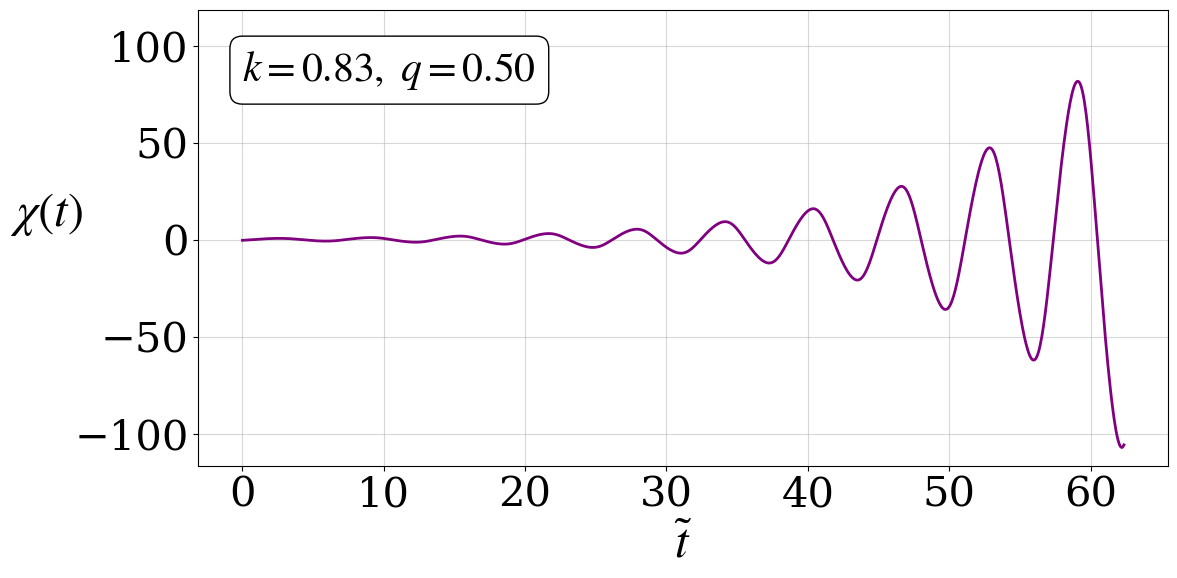

In [5]:
# Condiciones iniciales
y0 = CI(kn, qn)
phi0, phi_dot0 = y0[0], y0[1]

# Tiempos
Tosc = oscilation(0.5 * phi_dot0**2 + 0.25 * phi0**4)
t_span = (0, 10 * Tosc)

sol_narrow = solve_ivp(pert, t_span, y0, t_eval=np.linspace(t_span[0], t_span[-1], 1000), method='RK45', rtol=1e-6, args=(kn, qn))

plt.figure(figsize=(12, 6))
plt.plot(sol_narrow.t, sol_narrow.y[2], lw = 2, color = "purple")
ymin, ymax = plt.gca().get_ylim()
plt.ylim(ymin, ymax*1.3)
plt.xlabel(r'$\tilde{t}$', fontsize = 35)
plt.ylabel(r'$\chi(t)$', labelpad=20, rotation='horizontal', fontsize = 35)
plt.text(x=sol_narrow.t[0], y=ymax*0.9, s=rf'$k = {kn:.2f}, ~ q = {qn:.2f}$', fontsize=30, bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'))
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
plt.tight_layout()
plt.grid(alpha=0.5)
#plt.show()
plt.savefig("Narrow_Resonance_lphi4.pdf", format = "pdf")

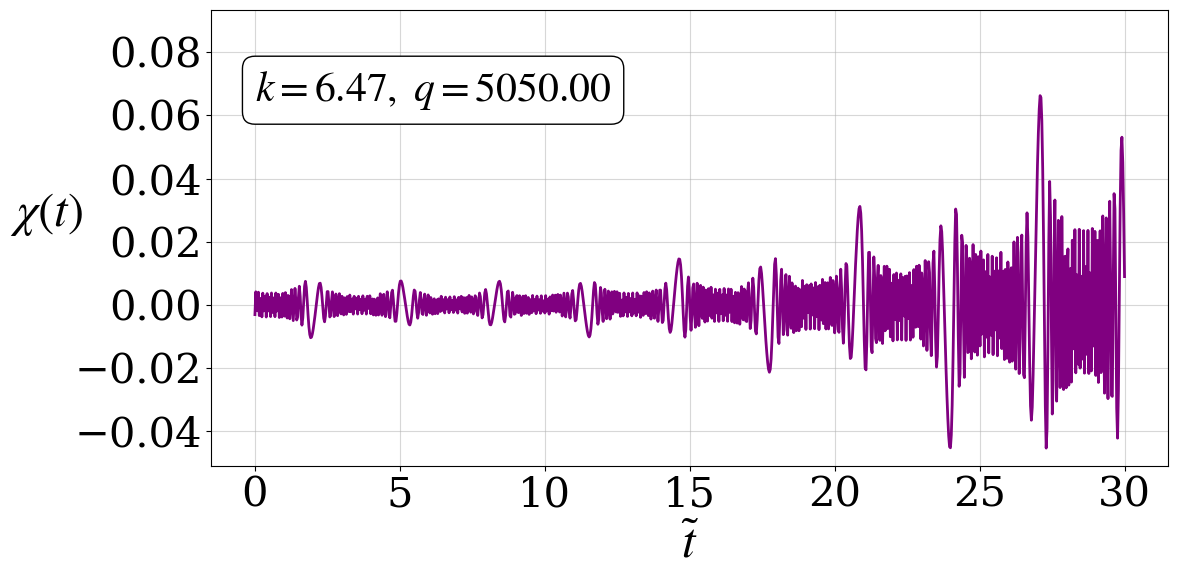

In [6]:
# Condiciones iniciales
y0 = CI(kb, qb)
phi0, phi_dot0 = y0[0], y0[1]

# Tiempos
Tosc = oscilation(0.5 * phi_dot0**2 + 0.25 * phi0**4)
t_span = (0, 10 * Tosc)

sol_broad = solve_ivp(pert, t_span, y0, t_eval=np.linspace(t_span[0], 30, 1000), method='RK45', rtol=1e-6, args=(kb, qb))

plt.figure(figsize=(12, 6))
plt.plot(sol_broad.t, sol_broad.y[2], lw = 2, color = "purple")
plt.grid(alpha=0.5)
ymin, ymax = plt.gca().get_ylim()
plt.ylim(ymin, ymax*1.3)
plt.xlabel(r'$\tilde{t}$', fontsize = 35)
plt.ylabel(r'$\chi(t)$', labelpad=20, rotation='horizontal', fontsize = 35)
plt.text(x=sol_broad.t[0], y=ymax*0.9, s=rf'$k = {kb:.2f}, ~ q = {qb:.2f}$', fontsize=30, bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'))
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
plt.tight_layout()
#plt.show()
plt.savefig("Broad_Resonance_lphi4.pdf", format = "pdf")

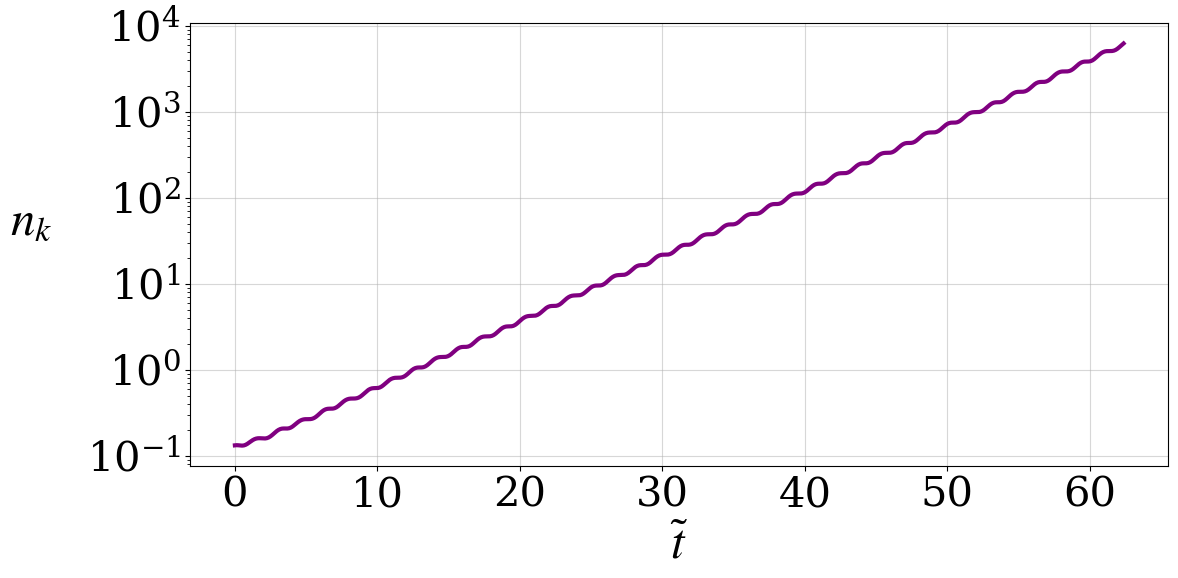

In [7]:
nk, omegak = number(kn, qn, sol_narrow.y[0], sol_narrow.y[2], sol_narrow.y[3], 1)
t = sol_narrow.t

plt.figure(figsize=(12, 6))
plt.semilogy(t, nk, lw = 3, color = "purple")
plt.xlabel(r'$\tilde{t}$', fontsize = 35)
plt.ylabel(r'$n_k$', fontsize = 35, rotation='horizontal', labelpad=40)
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
plt.grid(alpha=0.5)
plt.tight_layout()
#plt.show()
plt.savefig("nk_Narrow_Resonance_lphi4.pdf", format = "pdf")

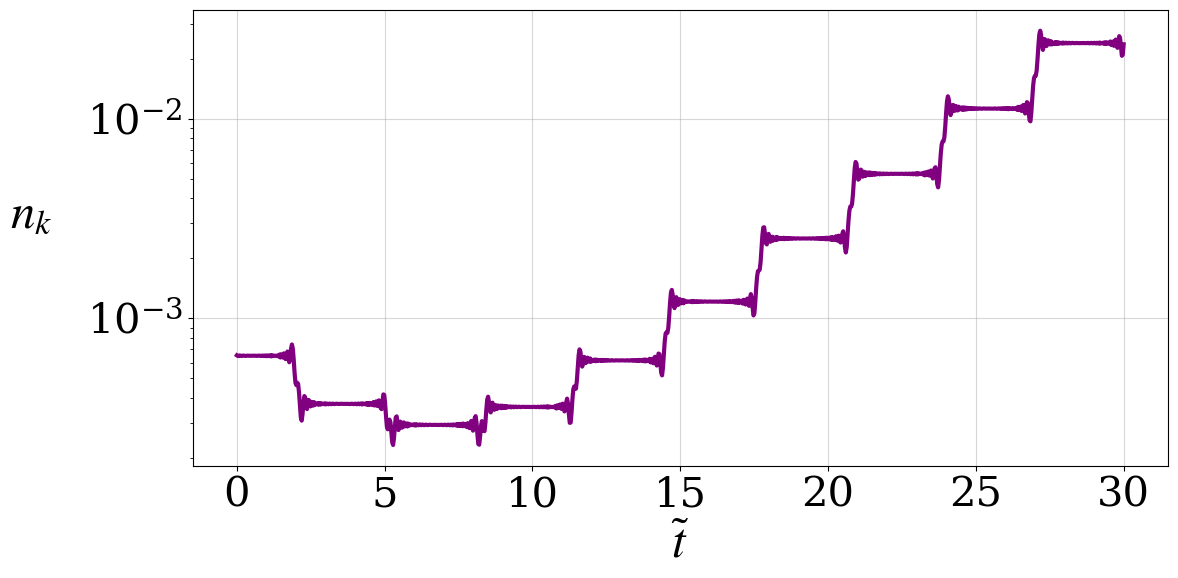

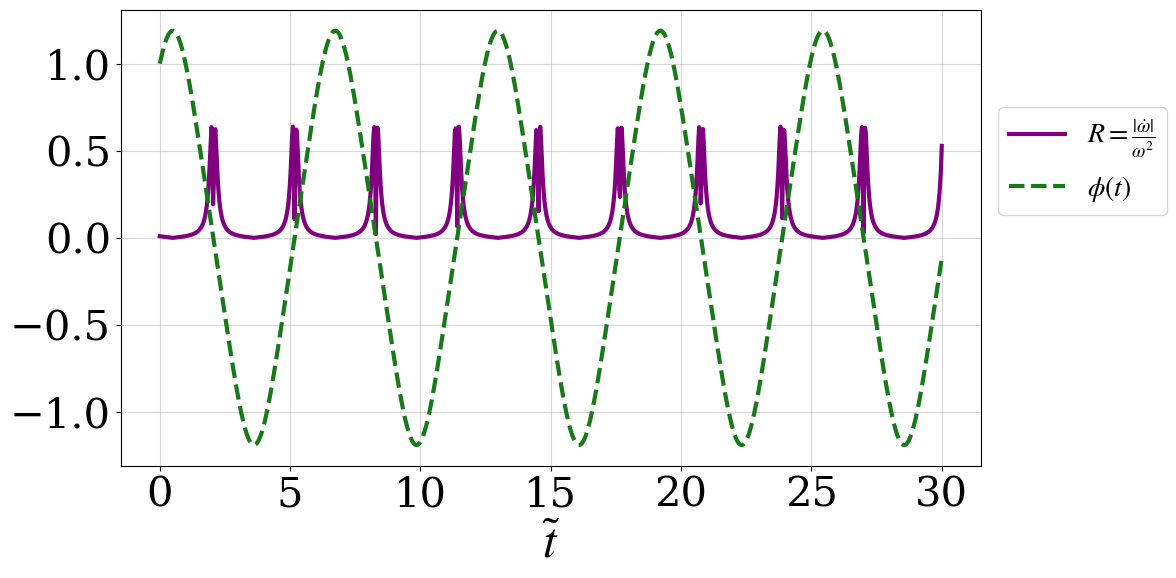

In [8]:
nk, omegak = number(kb, qb, sol_broad.y[0], sol_broad.y[2], sol_broad.y[3], 1)
t = sol_broad.t

plt.figure(figsize=(12, 6))
plt.semilogy(t, nk, lw = 3, color = "purple")
plt.xlabel(r'$\tilde{t}$', fontsize = 35)
plt.ylabel(r'$n_k$', fontsize = 35, rotation='horizontal', labelpad=40)
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
plt.grid(alpha=0.5)
plt.tight_layout()
#plt.show()
plt.savefig("nk_Broad_Resonance_lphi4.pdf", format = "pdf")


omegak_prime = np.gradient(omegak, t)
adiabaticity = np.abs(omegak_prime) / omegak**2
plt.figure(figsize=(12, 6))
plt.plot(t, adiabaticity, lw = 3, color = "purple", label = r'$R = \frac{|\dot{\omega}|}{\omega^2}$')
plt.plot(t, sol_broad.y[0], lw = 3, color = "#177917", label = r'$\phi(t)$', ls = "--")
plt.xlabel(r'$\tilde{t}$', fontsize = 35)
plt.legend(fontsize = 20, loc = (1.02,0.55))
#plt.ylabel(r'$R$', fontsize = 35, rotation='horizontal', labelpad=40)
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
#plt.yscale('log')
plt.grid(alpha=0.5)
plt.tight_layout()
#plt.show()
plt.savefig("Adiabaticity_lphi4.pdf", format = "pdf")

## Expansión

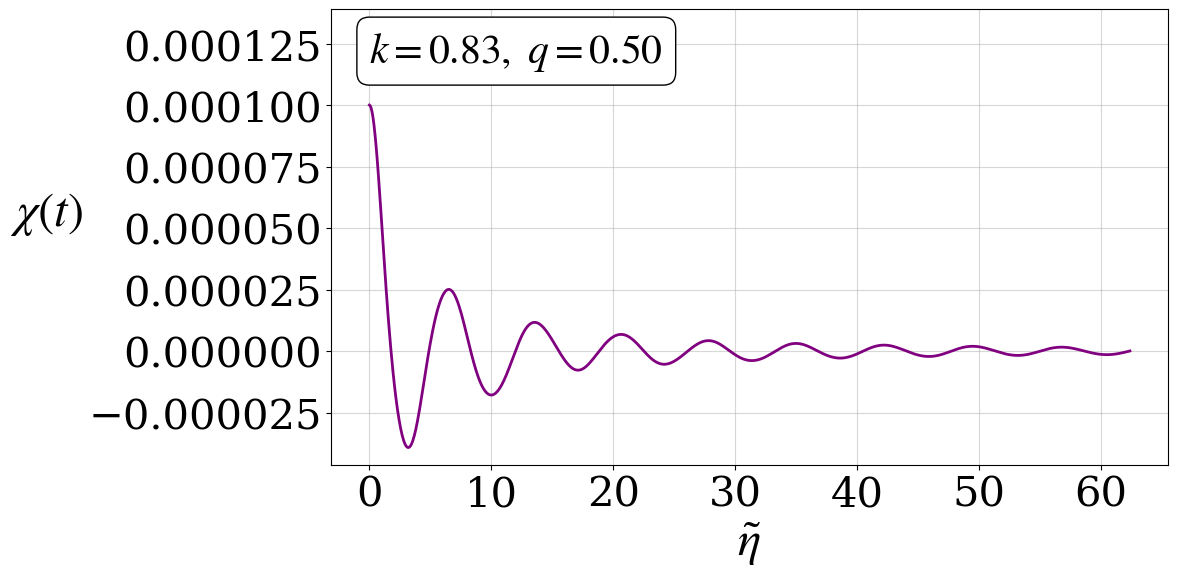

In [9]:
# Narrow Resonance
qn = 0.5
kn = 0.8277856966198477

y0 = CI_exp(kn, qn)
phi0, phi_dot0 = y0[0], y0[1]

# Tiempos
Tosc = oscilation(0.5 * phi_dot0**2 + 0.25 * phi0**4)
t_span = (0, 10 * Tosc)
eta = np.linspace(t_span[0], t_span[-1], 1000)

# Parámetros para la expansión del universo
C = phi0/np.sqrt(6) #np.sqrt((phi_dot0**2/2 + phi0**4/4) / 3)

sol_narrow_exp = solve_ivp(pert_exp, t_span, y0, t_eval=eta, method='RK45', rtol=1e-6, args=(kn, qn, C))

plt.figure(figsize=(12, 6))
plt.plot(sol_narrow_exp.t, sol_narrow_exp.y[2], lw = 2, color = "purple")
ymin, ymax = plt.gca().get_ylim()
plt.ylim(ymin, ymax*1.3)
plt.xlabel(r'$\tilde{\eta}$', fontsize = 35)
plt.ylabel(r'$\chi(t)$', labelpad=30, rotation='horizontal', fontsize = 35)
plt.text(x=sol_narrow_exp.t[0], y=ymax*1.1, s=rf'$k = {kn:.2f}, ~ q = {qn:.2f}$', fontsize=30, bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'))
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
plt.tight_layout()
plt.grid(alpha=0.5)
#plt.show()

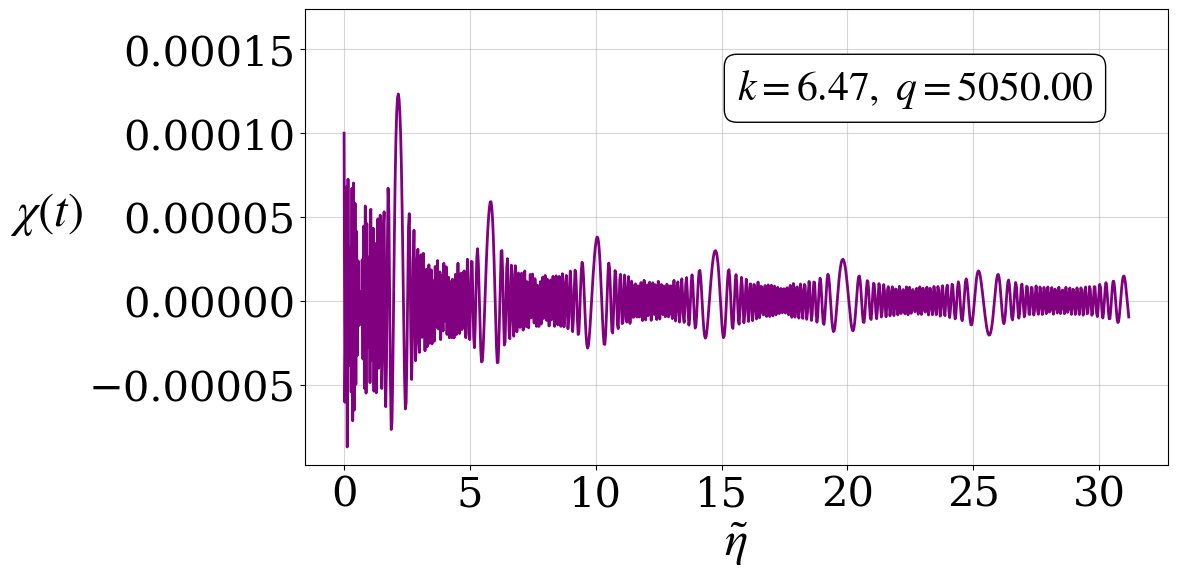

In [10]:
# Broad Resonance
qb = 5050
kb = 6.4686076615463275

y0 = CI_exp(kb, qb)
phi0, phi_dot0 = y0[0], y0[1]

# Tiempos
Tosc = oscilation(0.5 * phi_dot0**2 + 0.25 * phi0**4)
t_span = (0, 5 * Tosc)
eta = np.linspace(t_span[0], t_span[-1], 1000)

# Parámetros para la expansión del universo
C = phi0/np.sqrt(6) #np.sqrt((phi_dot0**2/2 + phi0**4/4) / 3)

sol_broad_exp = solve_ivp(pert_exp, t_span, y0, t_eval=eta, method='RK45', rtol=1e-6, args=(kb, qb, C))

plt.figure(figsize=(12, 6))
plt.plot(sol_broad_exp.t, sol_broad_exp.y[2], lw = 2, color = "purple")
ymin, ymax = plt.gca().get_ylim()
plt.ylim(ymin, ymax*1.3)
plt.xlabel(r'$\tilde{\eta}$', fontsize = 35)
plt.ylabel(r'$\chi(t)$', labelpad=30, rotation='horizontal', fontsize = 35)
plt.text(x=sol_broad_exp.t[-500], y=ymax*0.9, s=rf'$k = {kb:.2f}, ~ q = {qb:.2f}$', fontsize=30, bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'))
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
plt.tight_layout()
plt.grid(alpha=0.5)
#plt.show()

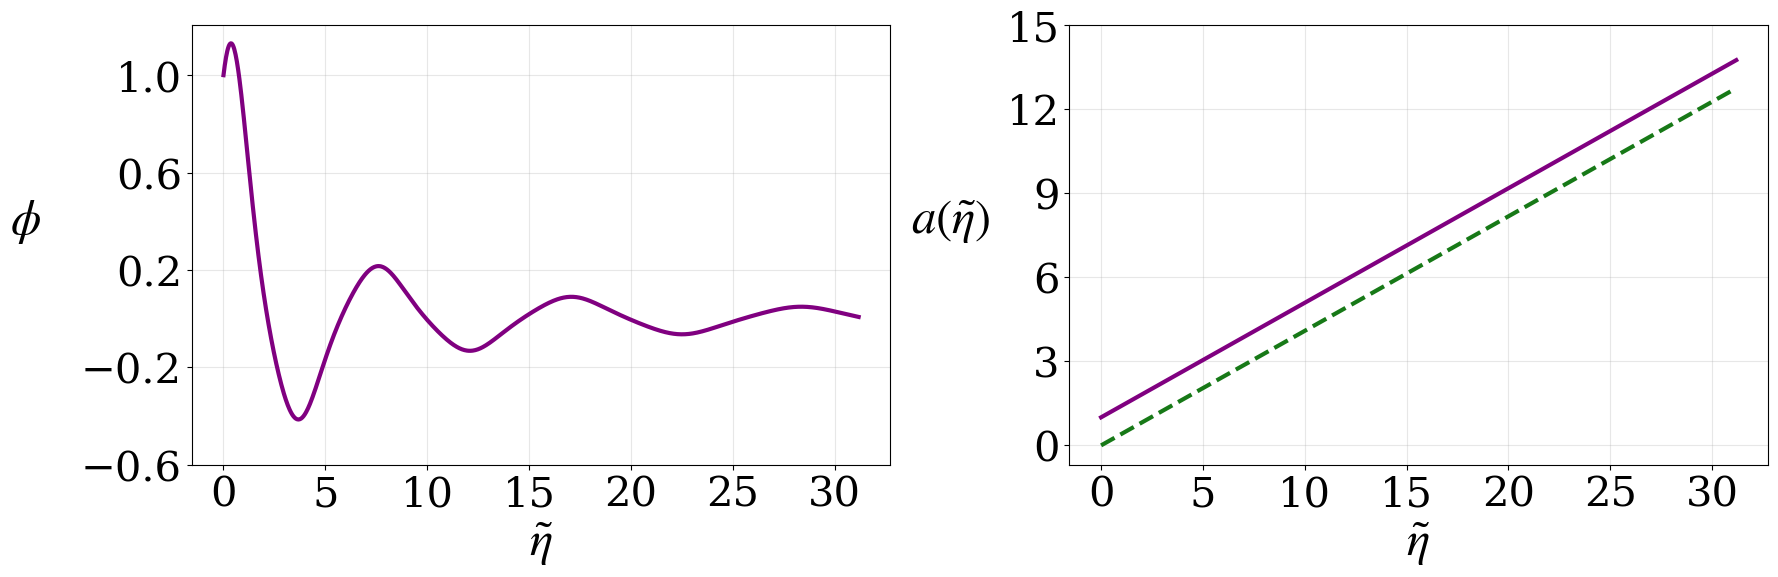

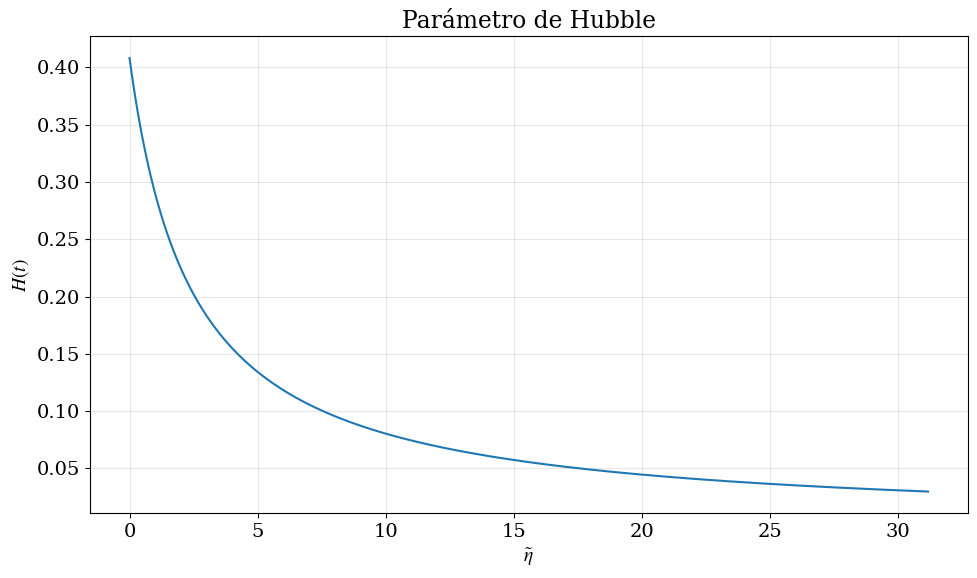

In [11]:
# Background y escala de expansión

a = 1 + C * sol_broad_exp.t
H = np.gradient(a, sol_broad_exp.t) / a

plt.figure(figsize=(18, 6))
plt.subplot(1, 2, 1)
plt.plot(sol_broad_exp.t, sol_broad_exp.y[0],lw = 3, color = "purple")
plt.xlabel(r'$\tilde{\eta}$', fontsize = 35)
plt.ylabel(r'$\phi$', fontsize = 35, rotation='horizontal', labelpad=40)
plt.xticks(fontsize=30)
plt.yticks(np.arange(-0.6, 1.2, 0.4), fontsize=30)
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(sol_broad_exp.t, a, lw = 3, color = "purple")
plt.plot(sol_broad_exp.t, C*sol_broad_exp.t, lw = 3, color = "#177917", ls = "--")
plt.xlabel(r'$\tilde{\eta}$', fontsize = 35)
plt.ylabel(r'$a(\tilde{\eta})$', fontsize = 35, rotation='horizontal', labelpad=40)
plt.xticks(fontsize=30)
plt.yticks(np.arange(0, 18, 3), fontsize=30)
plt.grid(alpha=0.3)

plt.tight_layout()
#plt.show()
plt.savefig("Background_lphi4.pdf", format = "pdf")

plt.figure(figsize=(10, 6))
plt.plot(sol_broad_exp.t, H, label=r'$\chi_k(t)$')
plt.xlabel(r'$\tilde{\eta}$')
plt.ylabel(r'$H(t)$')
plt.title(r'Parámetro de Hubble')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

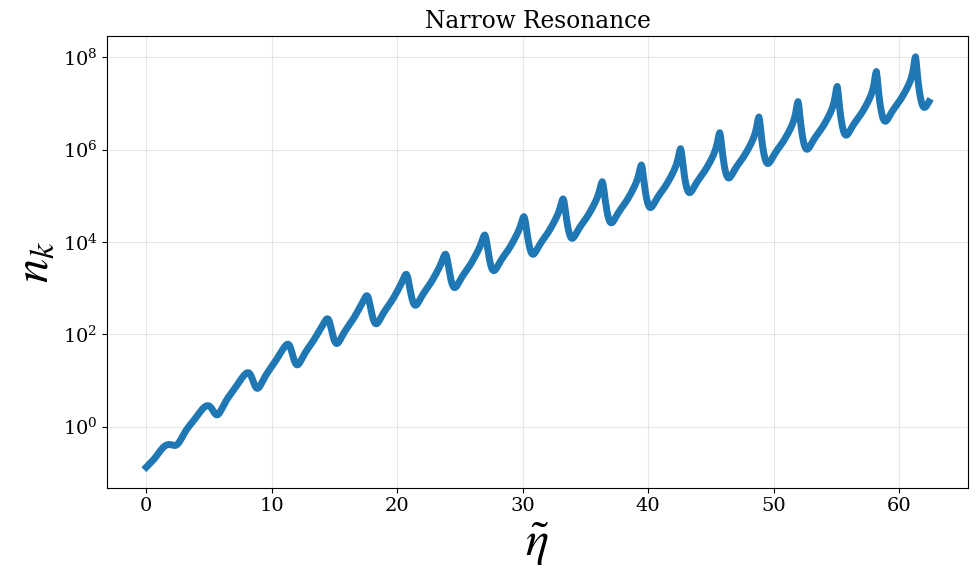

In [12]:
nk, omegak = number_exp(kn, qn, sol_narrow.y[0], sol_narrow.y[2], sol_narrow.y[3], a)
t = sol_narrow.t

plt.figure(figsize=(10, 6))
plt.semilogy(t, nk, lw = 5)
plt.xlabel(r'$\tilde{\eta}$', fontsize = 35)
plt.ylabel(r'$n_k$', fontsize = 35)
plt.title(r'Narrow Resonance')
plt.grid(alpha=0.3)
plt.tight_layout()
#plt.show()
plt.savefig("nk_Narrow_Resonance_lphi4_exp.pdf", format = "pdf")

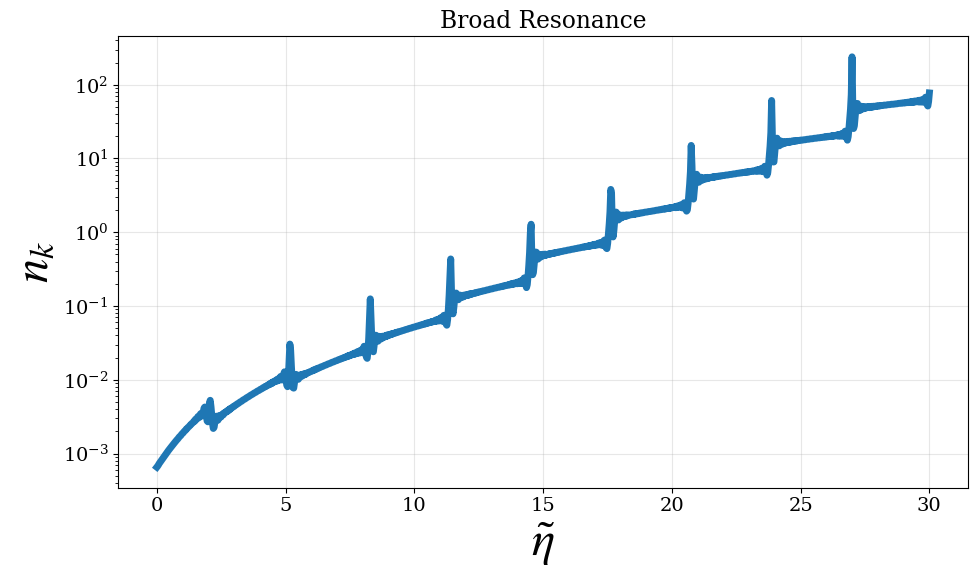

In [13]:
nk, omegak = number_exp(kb, qb, sol_broad.y[0], sol_broad.y[2], sol_broad.y[3], a)
t = sol_broad.t

plt.figure(figsize=(10, 6))
plt.semilogy(t, nk, lw = 5)
plt.xlabel(r'$\tilde{\eta}$', fontsize = 35)
plt.ylabel(r'$n_k$', fontsize = 35)
plt.title(r'Broad Resonance')
plt.grid(alpha=0.3)
plt.tight_layout()
#plt.show()
plt.savefig("nk_Broad_Resonance_lphi4_exp.pdf", format = "pdf")